[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multi_Step_Forecasting_Strategies.ipynb)

# Tomorrow, Three Ways: Recursive, Direct, Multi-Output
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

The capstone forecast 24 hours at once with `Dense(24)`. That is one of **three** ways to get from a one-step model to a whole day, and the one most people try first is the one with a trap in it:

| strategy | how | the catch |
| :-- | :-- | :-- |
| **Recursive** (autoregressive) | one model, one hour ahead; feed the prediction back in as "last hour" and roll forward 24 times | your own errors become tomorrow's inputs - and the covariates at future hours have to come from *somewhere* |
| **Direct** | one model per horizon: a 1-hour model, a 2-hour model, ... a 24-hour model | 24 models to train and maintain; nothing ties the horizons together |
| **Multi-output** (MIMO) | one model, `Dense(24)` - the capstone | one shot, no rolling; the model has to learn the whole daily shape at once |

You'll build all three on the same data and plot **error by horizon** for each. Then the question that trips everyone up in practice: when past demand is a feature, *what goes in that column for the hours you haven't seen yet?*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 18 — Tomorrow, three ways: recursive, direct, multi-output
- Setup: the capstone's multivariate one-step LSTM (last 24 hours -> next hour, demand's own past in the window). The question: how do you get 24 hours out of it?
- RECURSIVE: predict hour 1, write it into the demand column, slide the window, predict hour 2... Draw the window sliding on screen. The trap: after a few steps the window is mostly your own guesses.
- The covariate problem is the point of the video: for the future rows you need the clock (known - free), the weather (NOT known - use a forecast; here we cheat with the actuals and CALL it perfect foresight, then show the honest version with the weather frozen), and past demand (your own predictions).
- Exposure bias: the model trained on TRUE past demand, then runs on its own predictions. Errors compound - read the curve: 33 MW at hour 1 (best of everything), 331 at hour 24 with perfect weather, 414 with the weather frozen - WORSE than seasonal naive (227) from about hour 8 on.
- DIRECT: retrain the same model with the target shifted h hours out - a separate model per horizon (we do 1, 6, 12, 24: 42 / 142 / 178 / 207 MW). No rolling, no fake inputs; the cost is 24 models.
- MULTI-OUTPUT: Dense(24), the capstone. One model, one shot: 87 / 139 / 171 / 206 MW - weak at hour 1 (it's learning the whole day at once), tied with direct by hour 24, and both beat seasonal naive. Say which you'd ship and why (direct/MIMO for ops; recursive only for the first few hours).
- Real life: the weather column at future hours comes from the NWS forecast (we have a pipeline for that in class) - and the forecast's error becomes yours.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Data and the one-step engine

Same prep as the capstone. The one-step LSTM is the engine every strategy starts from.

In [2]:
# same prep as the demand capstone: sort, fill, clock features, Demand LAST, train 2017-18 / test 2019
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"]).sort_values("Datetime").set_index("Datetime").ffill()

def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
data  = add_clock(df.loc["2017-01-01":"2019-12-31"])[feats]
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]

sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # target-only scaler to get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)

def split_sequences(seqs, n_steps, horizon=1):
    """inputs = the past n_steps rows (every column); target = Demand `horizon` steps after the window ends"""
    X, y = [], []
    for i in range(len(seqs) - n_steps - horizon + 1):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps+horizon-1, -1])
    return np.array(X), np.array(y)

n_steps = 24
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (17496, 24, 8) | test: (8736, 24, 8)


In [3]:
one_step = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(1)])
one_step.compile(optimizer="adam", loss="mse", metrics=["mae"])
one_step.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_1h = sc_y.inverse_transform(one_step.predict(X_test, verbose=0)).ravel()
print(f"one-step LSTM, 1 hour ahead: MAE {mean_absolute_error(y_true, pred_1h):.1f} MW")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


one-step LSTM, 1 hour ahead: MAE 33.4 MW


## Strategy 1: recursive (autoregressive)

Take the last 24 real hours, predict hour +1. Now build the row for hour +1: the **clock** we know, the **weather** we... don't (more on that below), and **demand** is the number we just predicted. Slide the window forward one row and predict hour +2. Repeat 24 times.

The model was trained where the demand column was always *true* history. At forecast time it sees its own guesses in that column - that mismatch has a name, **exposure bias** - and every error it makes becomes part of tomorrow's input.

In [4]:
def recursive_forecast(model, seqs, n_steps, n_out, weather_cols, mode="actual"):
    """Roll a one-step model n_out steps ahead from EVERY window in seqs.
    mode='actual'  -> future weather rows come from the real future (perfect foresight - a cheat, labelled as such)
    mode='persist' -> future weather is frozen at the last observed hour (what you'd have with no forecast)"""
    n_orig = len(seqs) - n_steps - n_out + 1
    window = np.stack([seqs[i:i+n_steps] for i in range(n_orig)])          # (origins, 24, 8) - all real history
    preds = np.zeros((n_orig, n_out))
    for h in range(n_out):
        p = model.predict(window, verbose=0).ravel()                          # predict the next hour for every origin at once
        preds[:, h] = p
        future = np.stack([seqs[i+n_steps+h] for i in range(n_orig)]).copy() # the real row for hour +h+1 (we only take the clock from it)
        if mode == "persist":
            future[:, weather_cols] = window[:, -1, weather_cols]            # no forecast: freeze the weather
        future[:, -1] = p                                                    # the demand column is OUR PREDICTION now
        window = np.concatenate([window[:, 1:, :], future[:, None, :]], axis=1)   # slide the window
    return preds

n_out = 24
weather_cols = [feats.index(c) for c in ["BDL_tmpf", "BDL_dwpf", "BDL_relh"]]
rec_actual  = recursive_forecast(one_step, te_s, n_steps, n_out, weather_cols, mode="actual")
rec_persist = recursive_forecast(one_step, te_s, n_steps, n_out, weather_cols, mode="persist")

# truth for the same origins and horizons, in MW
n_orig = rec_actual.shape[0]
truth = np.stack([te_s[i+n_steps:i+n_steps+n_out, -1] for i in range(n_orig)])
to_mw = lambda a: sc_y.inverse_transform(a.reshape(-1, 1)).reshape(a.shape)
truth_mw, rec_actual_mw, rec_persist_mw = to_mw(truth), to_mw(rec_actual), to_mw(rec_persist)

mae_rec_actual  = np.abs(rec_actual_mw  - truth_mw).mean(axis=0)
mae_rec_persist = np.abs(rec_persist_mw - truth_mw).mean(axis=0)
print("recursive, perfect-foresight weather - MAE at h=1, 6, 12, 24:", mae_rec_actual[[0, 5, 11, 23]].round(1))
print("recursive, weather frozen          - MAE at h=1, 6, 12, 24:", mae_rec_persist[[0, 5, 11, 23]].round(1))

recursive, perfect-foresight weather - MAE at h=1, 6, 12, 24: [ 33.3 159.3 236.3 330.9]
recursive, weather frozen          - MAE at h=1, 6, 12, 24: [ 33.3 167.7 265.2 413.6]


## Strategy 2: direct (one model per horizon)

Same window, but the target is demand **h hours after the window ends**. Nothing is fed back, so there is no exposure bias - the model at horizon 12 learned, from real data, what 12 hours of drift looks like. The price: one model per horizon. We train four (1, 6, 12, 24) to see the curve; production would train all 24.

In [5]:
direct_h, direct_mae = [1, 6, 12, 24], []
for h in direct_h:
    Xh_tr, yh_tr = split_sequences(tr_s, n_steps, horizon=h)
    Xh_te, yh_te = split_sequences(te_s, n_steps, horizon=h)
    m = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(1)])
    m.compile(optimizer="adam", loss="mse")
    m.fit(Xh_tr, yh_tr, epochs=25, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
    # score on the same origins as the recursive run (first n_orig windows)
    p = sc_y.inverse_transform(m.predict(Xh_te[:n_orig], verbose=0)).ravel()
    t = sc_y.inverse_transform(yh_te[:n_orig].reshape(-1, 1)).ravel()
    direct_mae.append(mean_absolute_error(t, p))
    print(f"direct model, {h:2d} hours ahead: MAE {direct_mae[-1]:.1f} MW")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


direct model,  1 hours ahead: MAE 42.0 MW


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


direct model,  6 hours ahead: MAE 142.1 MW


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


direct model, 12 hours ahead: MAE 177.8 MW


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


direct model, 24 hours ahead: MAE 206.6 MW


## Strategy 3: multi-output (`Dense(24)`)

The capstone's approach: one model, 24 outputs, no rolling. Same 24-hour window so the comparison is fair.

In [6]:
def split_multistep(seqs, n_in, n_out):
    X, y = [], []
    for i in range(len(seqs) - n_in - n_out + 1):
        X.append(seqs[i:i+n_in, :]); y.append(seqs[i+n_in:i+n_in+n_out, -1])
    return np.array(X), np.array(y)

Xm_tr, ym_tr = split_multistep(tr_s, n_steps, n_out)
Xm_te, ym_te = split_multistep(te_s, n_steps, n_out)
mimo = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(n_out)])
mimo.compile(optimizer="adam", loss="mse", metrics=["mae"])
mimo.fit(Xm_tr, ym_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
mimo_mw = to_mw(mimo.predict(Xm_te, verbose=0))
mae_mimo = np.abs(mimo_mw - to_mw(ym_te)).mean(axis=0)
print("multi-output - MAE at h=1, 6, 12, 24:", mae_mimo[[0, 5, 11, 23]].round(1))

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


multi-output - MAE at h=1, 6, 12, 24: [ 87.3 138.8 170.9 205.9]


## Error by horizon - all three, against seasonal naive

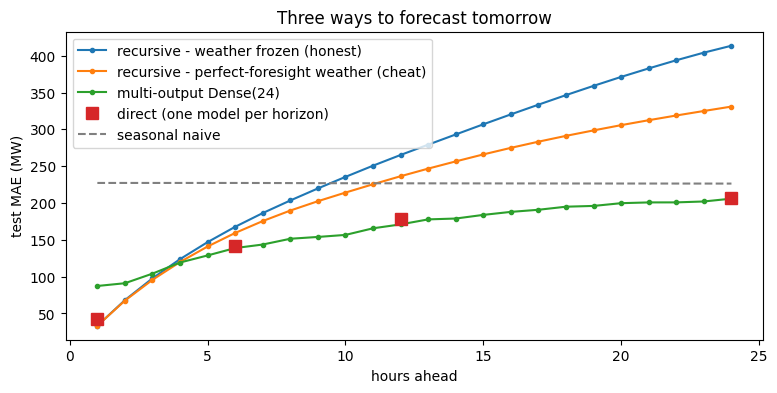

,recursive (frozen wx),recursive (perfect wx),direct,multi-output,seasonal naive
h=1,33.3,33.3,42.0,87.3,227.2
h=6,167.7,159.3,142.1,138.8,227.2
h=12,265.2,236.3,177.8,170.9,226.7
h=24,413.6,330.9,206.6,205.9,226.3


In [7]:
dem = test["Demand"].values
naive = np.array([mean_absolute_error(dem[n_steps+h:n_steps+h+n_orig], dem[n_steps+h-24:n_steps+h-24+n_orig]) for h in range(n_out)])

hrs = np.arange(1, n_out+1)
plt.figure(figsize=(9, 4))
plt.plot(hrs, mae_rec_persist, marker=".", label="recursive - weather frozen (honest)")
plt.plot(hrs, mae_rec_actual,  marker=".", label="recursive - perfect-foresight weather (cheat)")
plt.plot(hrs, mae_mimo,        marker=".", label="multi-output Dense(24)")
plt.plot(direct_h, direct_mae, "s", ms=8, label="direct (one model per horizon)")
plt.plot(hrs, naive, "--", color="gray", label="seasonal naive")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)"); plt.title("Three ways to forecast tomorrow"); plt.legend(); plt.show()

pd.DataFrame({"recursive (frozen wx)": mae_rec_persist[[0, 5, 11, 23]], "recursive (perfect wx)": mae_rec_actual[[0, 5, 11, 23]],
              "direct": direct_mae, "multi-output": mae_mimo[[0, 5, 11, 23]], "seasonal naive": naive[[0, 5, 11, 23]]},
             index=[f"h={h}" for h in direct_h]).round(1)

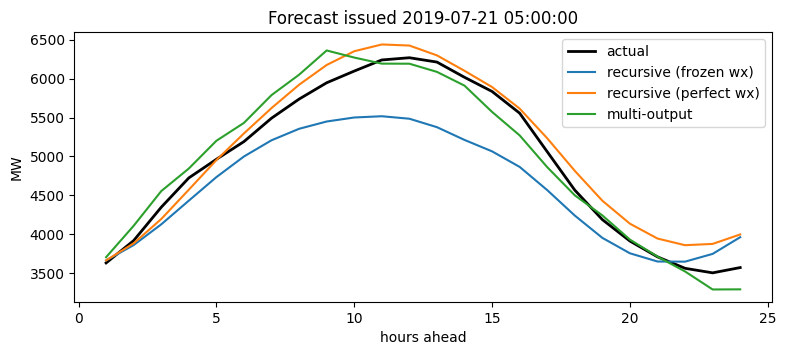

In [8]:
# one origin, the three forecasts and reality
o = 24*200 + 6      # a day in mid-July, forecast made at 6 AM
plt.figure(figsize=(9, 3.5))
plt.plot(hrs, truth_mw[o], "k", lw=2, label="actual")
plt.plot(hrs, rec_persist_mw[o], label="recursive (frozen wx)"); plt.plot(hrs, rec_actual_mw[o], label="recursive (perfect wx)")
plt.plot(hrs, mimo_mw[o], label="multi-output")
plt.xlabel("hours ahead"); plt.ylabel("MW"); plt.title(f"Forecast issued {test.index[o+n_steps-1]}"); plt.legend(); plt.show()

## Where do the future covariates come from?

The recursive strategy forced the question; it applies to *every* strategy that uses covariates at the target hour. Three kinds of column:

| column | at hour +h you have... | what to do |
| :-- | :-- | :-- |
| **calendar / clock** (hour, weekday, holiday) | the exact value - it's a calendar | use it; it's free and it's the strongest covariate after demand itself |
| **weather** (temperature, dew point, humidity) | *not* the actual - only a **forecast** | feed the NWS forecast for hour +h; the forecast's error becomes your error, so validate with *archived forecasts*, not actuals (the "perfect foresight" curve above is the optimistic bound) |
| **the target's own past** (demand) | actuals up to now, then nothing | recursive: your predictions (compounding); direct / multi-output: only real history goes in, the model learned the drift |

The professional pattern is **direct or multi-output with forecast weather** - no fake inputs, and the weather forecast error is explicit. Recursive is fine for a few steps and for models that are expensive to retrain per horizon.

**One more way, for later:** an *encoder-decoder* (seq2seq) RNN reads the window and then *generates* the next 24 values one at a time, trained with **teacher forcing** (the true previous value is fed in during training) - which is exactly the exposure-bias situation, made explicit and usually managed with scheduled sampling. That's the architecture that becomes machine translation in Module 5.

## Save the model and use it again

In [9]:
mimo.save('Multi_Step_Forecasting_Strategies_mimo.keras')
reloaded = load_model('Multi_Step_Forecasting_Strategies_mimo.keras')
print("reloaded model reproduces the forecast:", np.allclose(mimo.predict(Xm_te[:5], verbose=0), reloaded.predict(Xm_te[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Train all 24 direct models (a loop, ~10 minutes on CPU) and plot the full direct curve. Does it beat multi-output at every horizon?
- Recursive with a **week** of history (`n_steps = 168`). Does a longer window slow the error growth?
- Replace the frozen weather with *yesterday's weather at the same hour* (a poor person's forecast). Where does it land between the two recursive curves?
- Add a `holiday` column (`pandas.tseries.holiday.USFederalHolidayCalendar`) - a calendar covariate you know perfectly in advance.